In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
# === 1. Device Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Device:", device)

# === 2. Dataset Class ===
class RAFDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
        self.samples = []

        self.image_dict = {}
        for class_label in os.listdir(img_dir):
            class_folder = os.path.join(img_dir, class_label)
            if not os.path.isdir(class_folder):
                continue
            for file in os.listdir(class_folder):
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.image_dict[file] = os.path.join(class_folder, file)

        for _, row in self.df.iterrows():
            img_name = row["image"].replace("\\", "/")
            label = int(row["label"]) - 1
            if img_name in self.image_dict:
                self.samples.append((self.image_dict[img_name], label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

Device: cuda


In [3]:
# === 3. Transforms ===
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === 4. Load Data ===
train_dataset = RAFDataset("raf_db_dataset/train_split.csv", "raf_db_dataset/train", train_transform)
val_dataset = RAFDataset("raf_db_dataset/val_split.csv", "raf_db_dataset/train", val_test_transform)
test_dataset = RAFDataset("raf_db_dataset/test_labels.csv", "raf_db_dataset/test", val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [4]:
# === 5. Model Setup ===
model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 7)
)
model = model.to(device)

labels = [label for _, label in train_dataset]
class_sample_count = np.bincount(labels)
class_weights = torch.tensor(1.0 / class_sample_count, dtype=torch.float).to(device)

epochs = 50
criterion = None

# === 6. Optimizer, Scheduler, MixUp ===
from torch.optim.lr_scheduler import CosineAnnealingLR
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

scaler = torch.cuda.amp.GradScaler()

def mixup_data(x, y, alpha=0.5):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

/tmp/ipykernel_1453921/179793427.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [5]:
# === 7. Training Loop ===
best_val_acc = 0.0
patience = 5
epochs_no_improve = 0
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

print("Training...")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05 if epoch >= 20 else 0.0)

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            if epoch >= 10:
                x_mix, y_a, y_b, lam = mixup_data(x, y)
                outputs = model(x_mix)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                outputs = model(x)
                loss = criterion(outputs, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct / total)

    # === Validation ===
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_correct / val_total)
    scheduler.step()

    print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accuracies[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accuracies[-1]:.4f}")

    if val_accuracies[-1] > best_val_acc:
        best_val_acc = val_accuracies[-1]
        torch.save(model.state_dict(), "models/best_resnet50_rafdb.pth")
        epochs_no_improve = 0
        print("Best model saved!")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

Training...


Epoch 1/50: 100%|██████████| 82/82 [00:21<00:00,  3.79it/s]


Epoch 1 | Train Loss: 1.6471 | Train Acc: 0.3800 | Val Loss: 1.3395 | Val Acc: 0.5997
Best model saved!


Epoch 2/50: 100%|██████████| 82/82 [00:16<00:00,  4.87it/s]


Epoch 2 | Train Loss: 1.1077 | Train Acc: 0.6233 | Val Loss: 0.9968 | Val Acc: 0.6871
Best model saved!


...

Epoch 18 | Train Loss: 0.7437 | Train Acc: 0.6237 | Val Loss: 0.8281 | Val Acc: 0.8061
No improvement for 3 epoch(s)


Epoch 19/50: 100%|██████████| 82/82 [00:16<00:00,  5.09it/s]


Epoch 19 | Train Loss: 0.7229 | Train Acc: 0.6689 | Val Loss: 0.7684 | Val Acc: 0.8175
No improvement for 4 epoch(s)


Epoch 20/50: 100%|██████████| 82/82 [00:15<00:00,  5.20it/s]


Epoch 20 | Train Loss: 0.8006 | Train Acc: 0.5913 | Val Loss: 0.7605 | Val Acc: 0.8121
No improvement for 5 epoch(s)
Early stopping triggered.


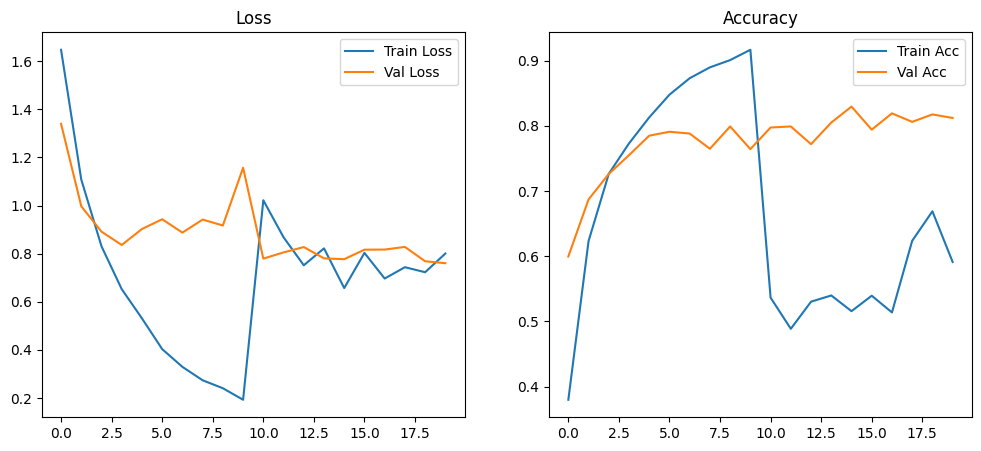

In [6]:
# === 8. Plot Metrics ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend(); plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.legend(); plt.title("Accuracy")
plt.show()


Test Accuracy: 0.8377
Test Loss: 25.5307


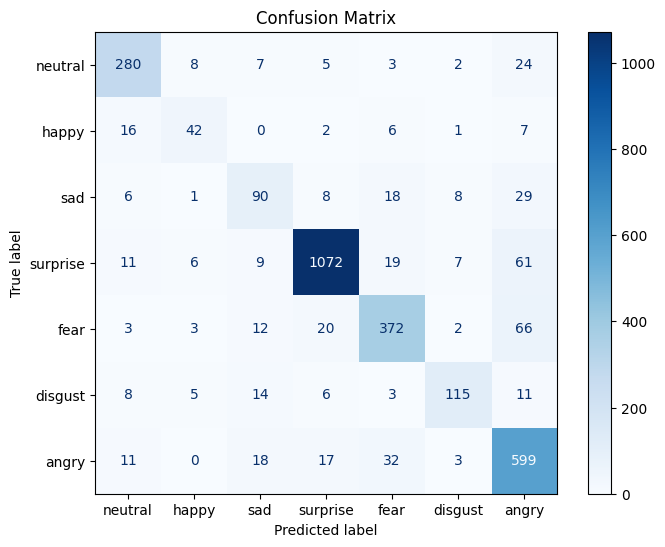

              precision    recall  f1-score   support

     neutral       0.84      0.85      0.84       329
       happy       0.65      0.57      0.60        74
         sad       0.60      0.56      0.58       160
    surprise       0.95      0.90      0.93      1185
        fear       0.82      0.78      0.80       478
     disgust       0.83      0.71      0.77       162
       angry       0.75      0.88      0.81       680

    accuracy                           0.84      3068
   macro avg       0.78      0.75      0.76      3068
weighted avg       0.84      0.84      0.84      3068



In [7]:
# === 9. Final Evaluation and Prediction ===
class_names = ["neutral", "happy", "sad", "surprise", "fear", "disgust", "angry"]

model.load_state_dict(torch.load("models/best_resnet50_rafdb.pth"))
model.eval()

all_preds, all_labels = [], []
test_loss, correct, total = 0.0, 0, 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)
        test_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(f"\nTest Accuracy: {correct / total:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(all_labels, all_preds, target_names=class_names))

In [8]:
from PIL import Image

def predict_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(image)
        pred = outputs.argmax(dim=1).item()
    print(f"Prediction: {class_names[pred]}")
    return class_names[pred]

# Example:
predict_image("raf_db_dataset/train/2/train_00027_aligned.jpg")

Prediction: happy


'happy'